<a href="https://colab.research.google.com/github/zennyMe17/QuantumComputing-BB84/blob/main/BB84_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# ✅ Step 1: Install the required packages
!pip install qiskit qiskit-aer

In [8]:
# ✅ Step 2: Imports (Updated for Qiskit 2.x)
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer

In [9]:
# ✅ Step 3: Helper Functions

def prepare_in_basis(qc, bit, basis):
    """Prepare qubit as |0>, |1>, |+>, or |->
       depending on bit and basis."""
    if bit == 1:
        qc.x(0)
    if basis == 'X':
        qc.h(0)
    return qc


def measure_in_basis(qc, basis):
    """Measure qubit in Z or X basis."""
    if basis == 'X':
        qc.h(0)
    qc.measure(0, 0)
    return qc


In [10]:
# ✅ Step 4: BB84 Simulation Function (Modern Qiskit Execution)
def bb84_simulation(num_qubits=12, eve_present=False):
    backend = Aer.get_backend('aer_simulator')
    alice_bits = np.random.randint(2, size=num_qubits)
    alice_bases = np.random.choice(['Z', 'X'], size=num_qubits)
    bob_bases = np.random.choice(['Z', 'X'], size=num_qubits)
    bob_results = []

    for i in range(num_qubits):
        qc = QuantumCircuit(1, 1)
        prepare_in_basis(qc, alice_bits[i], alice_bases[i])

        # Optional Eve interception
        if eve_present:
            eve_basis = np.random.choice(['Z', 'X'])
            measure_in_basis(qc, eve_basis)
            transpiled = transpile(qc, backend)
            result = backend.run(transpiled, shots=1).result()
            measured = int(list(result.get_counts().keys())[0])

            # Eve resends measured qubit
            qc = QuantumCircuit(1, 1)
            prepare_in_basis(qc, measured, eve_basis)

        # Bob measures
        measure_in_basis(qc, bob_bases[i])
        transpiled = transpile(qc, backend)
        result = backend.run(transpiled, shots=1).result()
        measured = int(list(result.get_counts().keys())[0])
        bob_results.append(measured)

    # Keep only qubits measured in the same basis
    same_basis = alice_bases == bob_bases
    key_alice = alice_bits[same_basis]
    key_bob = np.array(bob_results)[same_basis]

    return alice_bits, alice_bases, bob_bases, key_alice, key_bob

In [11]:
# ✅ Step 5: Run the Simulation

alice_bits, alice_bases, bob_bases, key_alice, key_bob = bb84_simulation(
    num_qubits=12,
    eve_present=True   # set to False for clean channel
)

print("Alice bits:  ", alice_bits)
print("Alice bases: ", alice_bases)
print("Bob bases:   ", bob_bases)
print("Alice key:   ", key_alice)
print("Bob key:     ", key_bob)
print("Error rate:  ", np.mean(key_alice != key_bob))

Alice bits:   [0 1 1 1 0 0 1 1 0 0 1 1]
Alice bases:  ['X' 'X' 'Z' 'X' 'X' 'Z' 'X' 'X' 'Z' 'Z' 'Z' 'X']
Bob bases:    ['Z' 'Z' 'Z' 'Z' 'X' 'Z' 'X' 'Z' 'X' 'X' 'X' 'X']
Alice key:    [1 0 0 1 1]
Bob key:      [1 1 1 1 1]
Error rate:   0.4


In [18]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

def prepare_qubit(bit, basis):
    qc = QuantumCircuit(1, 1)
    if bit == 1:
        qc.x(0)
    if basis == 'X':
        qc.h(0)
    return qc

def measure_qubit(qc, basis):
    if basis == 'X':
        qc.h(0)
    qc.measure(0, 0)
    return qc

def measure_result(result):
    # Extract the last bit safely (handles '0' or '0 0')
    counts = result.get_counts()
    key = list(counts.keys())[0].replace(" ", "")
    return int(key[-1])

def bb84_simulation(num_bits=20, eve_present=False, seed=None):
    if seed:
        np.random.seed(seed)
    backend = AerSimulator()

    alice_bits = np.random.randint(2, size=num_bits)
    alice_bases = np.random.choice(['Z', 'X'], size=num_bits)
    bob_bases   = np.random.choice(['Z', 'X'], size=num_bits)
    bob_results = []

    for i in range(num_bits):
        # Step 1: Alice prepares
        qc = prepare_qubit(alice_bits[i], alice_bases[i])

        # Step 2: Eve intercepts (optional)
        if eve_present:
            eve_basis = np.random.choice(['Z', 'X'])
            measure_qubit(qc, eve_basis)
            transpiled = transpile(qc, backend)
            result = backend.run(transpiled, shots=1).result()
            eve_bit = measure_result(result)
            # Eve resends
            qc = prepare_qubit(eve_bit, eve_basis)

        # Step 3: Bob measures
        measure_qubit(qc, bob_bases[i])
        transpiled = transpile(qc, backend)
        result = backend.run(transpiled, shots=1).result()
        bob_bit = measure_result(result)
        bob_results.append(bob_bit)

    # Sifting: keep only same-basis measurements
    mask = (alice_bases == bob_bases)
    key_alice = alice_bits[mask]
    key_bob   = np.array(bob_results)[mask]

    # Compute error rate
    if len(key_alice) > 0:
        qber = np.mean(key_alice != key_bob)
    else:
        qber = 0.0

    return alice_bits, alice_bases, bob_bases, key_alice, key_bob, qber

🧠 Eve present? False
Alice key: [1 0 0 0 1 0 0 1 0 0 1 1 1 0]
Bob key:   [1 0 0 0 1 0 0 1 0 0 1 1 1 0]
QBER: 0.00%


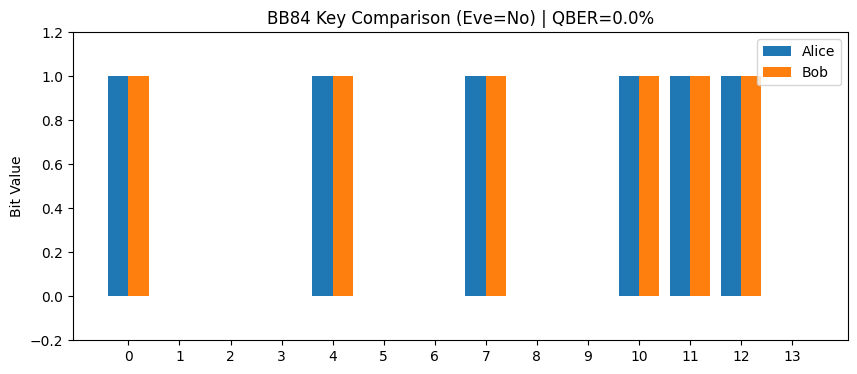

🧠 Eve present? True
Alice key: [1 0 0 0 1 0 0 1 0 0 1 1 1 0]
Bob key:   [1 0 0 1 1 0 0 1 0 0 1 0 1 0]
QBER: 14.29%


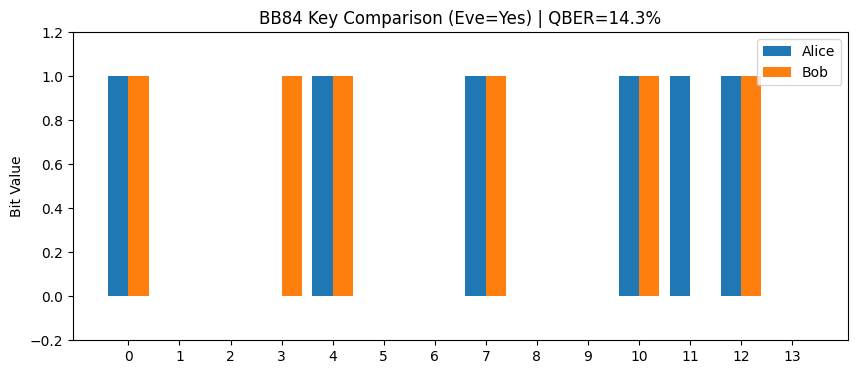

In [19]:
import matplotlib.pyplot as plt

def visualize_bb84(num_bits=20, eve_present=False, seed=None):
    alice_bits, alice_bases, bob_bases, key_a, key_b, qber = bb84_simulation(
        num_bits=num_bits, eve_present=eve_present, seed=seed
    )

    print("🧠 Eve present?", eve_present)
    print("Alice key:", key_a)
    print("Bob key:  ", key_b)
    print(f"QBER: {qber*100:.2f}%")

    # Plot keys
    n = len(key_a)
    x = np.arange(n)
    plt.figure(figsize=(10,4))
    plt.bar(x - 0.2, key_a, width=0.4, label="Alice")
    plt.bar(x + 0.2, key_b, width=0.4, label="Bob")
    plt.ylim(-0.2, 1.2)
    plt.xticks(x)
    plt.ylabel("Bit Value")
    plt.title(f"BB84 Key Comparison (Eve={'Yes' if eve_present else 'No'}) | QBER={qber*100:.1f}%")
    plt.legend()
    plt.show()

# ▶️ Run clean vs attacked
visualize_bb84(num_bits=20, eve_present=False, seed=42)
visualize_bb84(num_bits=20, eve_present=True, seed=42)